<a href="https://www.kaggle.com/code/chizkidd/efficientnet-cifar10?scriptVersionId=291710021" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

Deep Learning Models: A collection of various deep learning architectures, models, & their implementations (`PyTorch` or `TensorFlow`) in Jupyter Notebooks.
* Author: _Chizoba Obasi_
* Github Repo: https://github.com/chizkidd/deep-learning-models

In [1]:
!pip install watermark

In [2]:
!pip install torchinfo

In [3]:
%load_ext watermark
# %reload_ext watermark
%watermark -a 'Chizoba Obasi' -v -p torch

Author: Chizoba Obasi

Python implementation: CPython
Python version       : 3.11.13
IPython version      : 7.34.0

torch: 2.6.0+cu124



# EfficientNet-B0 Classifier on CIFAR-10
---

**Network Architecture:**

The network in this notebook is an implementation of the EfficientNet-B0 **[1]** architecture on the CIFAR-10 dataset to train an image classifier.  


![EfficientNet-B0baselinenetwork](https://velog.velcdn.com/images/tls991105/post/0c347a86-5a1c-4506-a913-8d5ef2b32a2d/image.png)
[Source](https://arxiv.org/pdf/1905.11946)


---
## EfficientNet: Model Architecture
![EfficientNet-B0-block](https://miro.medium.com/v2/resize:fit:720/format:webp/1*_8ACmO8lDanToRVTc1yemg.png?raw=1)

[Image Source](https://medium.com/@preeti.rana.ai/efficientnet-cv-ee225feaf9af)

---
**REFERENCES:**
1. Tan, M., & Le, Q. V. (2019). [EfficientNet: Rethinking model scaling for convolutional neural networks.](https://arxiv.org/abs/1905.11946) International Conference on Machine Learning, 6105–6114

In [4]:
import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.model_selection import train_test_split

from torchinfo import summary

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
%matplotlib inline

import pandas as pd
import numpy as np
import math
import time
import os
import random

if torch.cuda.is_available():
    torch.backends.cudnn.deterministic = True

In [5]:
def set_all_seeds(seed):
    os.environ["PL_GLOBAL_SEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def set_deterministic():
    if torch.cuda.is_available():
        torch.backends.cudnn.benchmark = False
        torch.backends.cudnn.deterministic = True
    torch.set_deterministic(True)

In [6]:
# Check if GPU is available and set the device
if torch.cuda.is_available():
    num_gpus = torch.cuda.device_count()
    print("Num GPUs Available: ", num_gpus)
    for i in range(num_gpus):
        gpu_name = torch.cuda.get_device_name(i)
        print(f"GPU {i}: {gpu_name}")
else:
    print("No GPU available.")

Num GPUs Available:  2
GPU 0: Tesla T4
GPU 1: Tesla T4


---
# 0. Model Hyperparameters
---

In [7]:
##########################
### SETTINGS
##########################

# Hyperparameters
RANDOM_SEED = 123
BATCH_SIZE = 128 #256
LEARNING_RATE = 0.001
NUM_EPOCHS = 30 #50
INPUT_SIZE = 32 # CIFAR-10 is 32x32
NUM_CLASSES = 10

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [8]:
set_all_seeds(RANDOM_SEED)

---
# 1. Data Preparation & Loading

---

In [9]:
# Mean and Std Dev for CIFAR-10 (3 channels)
CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD = (0.2471, 0.2435, 0.2616)

# Data Augmentation (Crucial for VGG-16 on CIFAR-10)
train_transforms = transforms.Compose([
    transforms.RandomCrop(32, padding=4),   # Crop after padding
    transforms.RandomHorizontalFlip(),      # Flip
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD) # Mean Subtraction
])

# Test/Validation Transforms (No Augmentation)
test_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD)
])

# Load Datasets
train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transforms)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transforms)

# Split training set into training and validation sets
train_size = int(0.9 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_subset, val_subset = torch.utils.data.random_split(train_dataset, [train_size, val_size])

# Create DataLoaders
train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

In [10]:
# Check that shuffling works properly
# i.e., label indices should be in random order.
# Also, the label order should be different in the second
# epoch.

for images, labels in train_loader:  
    pass
print(labels[:10])

for images, labels in train_loader:  
    pass
print(labels[:10])

tensor([1, 5, 5, 4, 2, 8, 5, 2, 4, 2])
tensor([9, 2, 4, 3, 7, 5, 8, 6, 2, 8])


In [11]:
# Check that validation set and test sets are diverse
# i.e., that they contain all classes

for images, labels in val_loader:  
    pass
print(labels[:10])

for images, labels in test_loader:  
    pass
print(labels[:10])

tensor([1, 6, 5, 9, 9, 0, 6, 6])
tensor([7, 5, 8, 0, 8, 2, 7, 0, 3, 5])


---
# 2. Model Creation

---

Building **EfficientNet-B0 from scratch** is a fantastic exercise because it introduces you to the **MBConv** (Mobile Inverted Bottleneck) block and **Squeeze-and-Excitation** (SE) optimization.

### Implementation Tips for "From Scratch":

* **Squeeze-and-Excitation Block:** This is the "secret sauce" that allows EfficientNet to weight channels dynamically.
* **`MBConv` Block:** This combines Depthwise-Separable convolutions with the SE block and a skip connection.
* **Activation Function:** EfficientNet uses **SiLU** (also known as Swish: ). Don't use ReLU, or it won't be a true EfficientNet.
* **Weights Initialization:** When training from scratch, use Kaiming Initialization for the Conv layers to help convergence.
* **Batch Size:** You can now use a larger batch size (like **128**) because you aren't upscaling images to 224x224.
  
_**Note:** In this scratch version, I have modified the **Strides** to `1` in the first few stages. This ensures that a **32x32** CIFAR-10 image doesn't shrink to 1x1 before the network is even half-finished._


In [12]:
class SqueezeExcitation(nn.Module):
    def __init__(self, in_channels, reduced_dim):
        super().__init__()
        self.se = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), # Squeeze
            nn.Conv2d(in_channels, reduced_dim, 1),
            nn.SiLU(),
            nn.Conv2d(reduced_dim, in_channels, 1),
            nn.Sigmoid() # Excitation
        )

    def forward(self, x):
        return x * self.se(x)

class MBConv(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride, expand_ratio, se_ratio=0.25):
        super().__init__()
        expand_channels = in_channels * expand_ratio
        self.use_residual = (stride == 1 and in_channels == out_channels)

        layers = []
        # 1. Expansion phase
        if expand_ratio != 1:
            layers.append(nn.Conv2d(in_channels, expand_channels, 1, bias=False))
            layers.append(nn.BatchNorm2d(expand_channels))
            layers.append(nn.SiLU())

        # 2. Depthwise phase
        layers.append(nn.Conv2d(expand_channels, expand_channels, kernel_size, 
                                stride, kernel_size//2, groups=expand_channels, bias=False))
        layers.append(nn.BatchNorm2d(expand_channels))
        layers.append(nn.SiLU())

        # 3. Squeeze and Excitation
        se_reduced_dim = int(in_channels * se_ratio)
        layers.append(SqueezeExcitation(expand_channels, se_reduced_dim))

        # 4. Pointwise phase (Projection)
        layers.append(nn.Conv2d(expand_channels, out_channels, 1, bias=False))
        layers.append(nn.BatchNorm2d(out_channels))

        self.block = nn.Sequential(*layers)

    def forward(self, x):
        if self.use_residual:
            return x + self.block(x)
        return self.block(x)

class EfficientNetB0(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        # Initial Conv: Changed stride 2 -> 1 for CIFAR-10
        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.SiLU()
        )

        # Configuration: [expand_ratio, channels, repeats, stride, kernel_size]
        self.config = [
            [1, 16, 1, 1, 3],
            [6, 24, 2, 1, 3], # Stride 1 for CIFAR (Standard is 2)
            [6, 40, 2, 2, 5],
            [6, 80, 3, 2, 3],
            [6, 112, 3, 1, 5],
            [6, 192, 4, 2, 5],
            [6, 320, 1, 1, 3],
        ]

        layers = []
        in_channels = 32
        for expand_ratio, out_channels, repeats, stride, kernel_size in self.config:
            for i in range(repeats):
                layers.append(MBConv(in_channels, out_channels, kernel_size, 
                                     stride if i == 0 else 1, expand_ratio))
                in_channels = out_channels
        self.layers = nn.Sequential(*layers)

        # Head
        self.head = nn.Sequential(
            nn.Conv2d(320, 1280, 1, bias=False),
            nn.BatchNorm2d(1280),
            nn.SiLU(),
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(0.2),
            nn.Linear(1280, num_classes)
        )

        # Initialize Weights
        self._initialize_weights()
        
    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                # Using fan_out for depthwise/pointwise layers
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x = self.stem(x)
        x = self.layers(x)
        x = self.head(x)
        return x

# Instantiate
model = EfficientNetB0().to(device)

In [13]:
# Model parameter details
summary(model,
        input_size=(BATCH_SIZE, 3, INPUT_SIZE, INPUT_SIZE),
        # verbose=1,
        col_names=["input_size", "output_size", "num_params", "kernel_size", "mult_adds"]
       )

Layer (type:depth-idx)                                  Input Shape               Output Shape              Param #                   Kernel Shape              Mult-Adds
EfficientNetB0                                          [128, 3, 32, 32]          [128, 10]                 --                        --                        --
├─Sequential: 1-1                                       [128, 3, 32, 32]          [128, 32, 32, 32]         --                        --                        --
│    └─Conv2d: 2-1                                      [128, 3, 32, 32]          [128, 32, 32, 32]         864                       [3, 3]                    113,246,208
│    └─BatchNorm2d: 2-2                                 [128, 32, 32, 32]         [128, 32, 32, 32]         64                        --                        8,192
│    └─SiLU: 2-3                                        [128, 32, 32, 32]         [128, 32, 32, 32]         --                        --                        --
├─S

---
# 3. Model Training, Testing & Evaluation

---

In [14]:
criterion = nn.CrossEntropyLoss()
# optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=5e-4)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=5e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

def calculate_accuracy(loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total

# Training Loop
start_time = time.time()
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'lrs': []}

print(f"Starting training on {device}...")

for epoch in range(NUM_EPOCHS):
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0
    
    for i, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        train_total += labels.size(0)
        train_correct += predicted.eq(labels).sum().item()

    train_loss = train_loss / len(train_subset)
    train_acc = 100. * train_correct / train_total
    
    # Calculate validation loss and accuracy
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()
    
    val_loss = val_loss / len(val_subset)
    val_acc = 100. * val_correct / val_total
    
    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']

    # Log metrics
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['lrs'].append(current_lr)

    print(f'Epoch {epoch + 1}/{NUM_EPOCHS} | '
          f'Train Loss: {train_loss:.5f}, '
          f'Train Acc.: {train_acc:.2f}% | '
          f'Val Loss: {val_loss:.5f}, '
          f'Val Acc.: {val_acc:.2f}% | '
          f'LR: {current_lr:.8f}'
          )

print('\nTotal Training Time: %.2f min' % ((time.time() - start_time)/60))

# --- Final Evaluation ---
test_accuracy = calculate_accuracy(test_loader)
print(f'\nTest Accuracy: {test_accuracy:.2f}%')

Starting training on cuda...
Epoch 1/30 | Train Loss: 1.60032, Train Acc.: 39.72% | Val Loss: 1.33364, Val Acc.: 51.76% | LR: 0.00099726
Epoch 2/30 | Train Loss: 1.08361, Train Acc.: 61.32% | Val Loss: 1.01320, Val Acc.: 64.06% | LR: 0.00098908
Epoch 3/30 | Train Loss: 0.85020, Train Acc.: 70.32% | Val Loss: 0.90244, Val Acc.: 68.76% | LR: 0.00097555
Epoch 4/30 | Train Loss: 0.72896, Train Acc.: 75.08% | Val Loss: 0.76207, Val Acc.: 74.44% | LR: 0.00095682
Epoch 5/30 | Train Loss: 0.64968, Train Acc.: 77.83% | Val Loss: 0.73072, Val Acc.: 74.96% | LR: 0.00093308
Epoch 6/30 | Train Loss: 0.59704, Train Acc.: 79.57% | Val Loss: 0.64726, Val Acc.: 78.36% | LR: 0.00090460
Epoch 7/30 | Train Loss: 0.55662, Train Acc.: 81.15% | Val Loss: 0.64641, Val Acc.: 77.54% | LR: 0.00087170
Epoch 8/30 | Train Loss: 0.51604, Train Acc.: 82.41% | Val Loss: 0.64870, Val Acc.: 78.00% | LR: 0.00083473
Epoch 9/30 | Train Loss: 0.48318, Train Acc.: 83.56% | Val Loss: 0.56256, Val Acc.: 80.92% | LR: 0.00079410

In [15]:
# --- Final Evaluation ---
test_accuracy = calculate_accuracy(test_loader)
print(f'\nTest Accuracy: {test_accuracy:.2f}%')


Test Accuracy: 89.93%


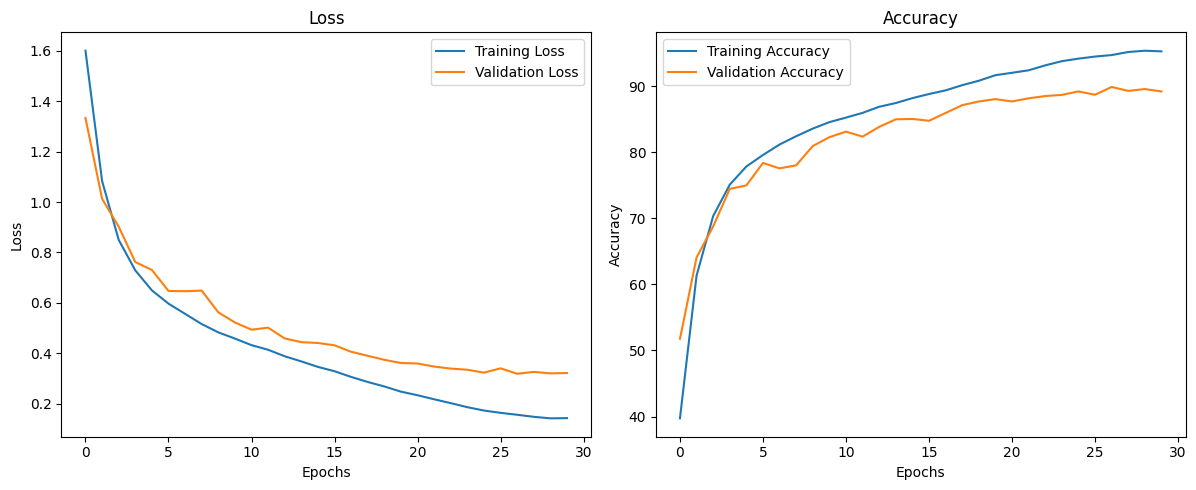

In [16]:
def plot_history(history):
    """
    Plots the training and validation loss, accuracy, and learning rate
    from a PyTorch history dictionary.

    Args:
        history (dict): Dictionary containing training metrics.
                        Expected keys: 'train_loss', 'val_loss', 'train_acc', 'val_acc', 'lrs'.
    """
    epochs = range(len(history['train_loss']))

    plt.figure(figsize=(18, 5))

    # Plot 1: Loss
    plt.subplot(1, 3, 1)
    plt.plot(epochs, history['train_loss'], label='Training Loss')
    plt.plot(epochs, history['val_loss'], label='Validation Loss')
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    # plt.grid(True)

    # Plot 2: Accuracy
    plt.subplot(1, 3, 2)
    plt.plot(epochs, history['train_acc'], label='Training Accuracy')
    plt.plot(epochs, history['val_acc'], label='Validation Accuracy')
    plt.title('Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    # plt.grid(True)

    plt.tight_layout()
    plt.show() 
    # plt.savefig() 

plot_history(history)

In [17]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

def _compute_confusion_matrix(model, data_loader, device):
    """
    Computes a confusion matrix for the given model and data.
    Uses scikit-learn for robustness and speed.
    """
    model.eval()
    all_targets = []
    all_predictions = []

    with torch.no_grad():
        for features, targets in data_loader:
            features = features.to(device)

            logits = model(features)
            _, predicted_labels = torch.max(logits, 1)

            # Move to CPU and convert to list/numpy immediately
            all_targets.extend(targets.view(-1).cpu().numpy())
            all_predictions.extend(predicted_labels.view(-1).cpu().numpy())

    return confusion_matrix(all_targets, all_predictions)

def _plot_confusion_matrix(mat, class_names):
    """
    Visualizes the confusion matrix using Seaborn for professional reporting.
    """
    plt.figure(figsize=(10, 8))
    sns.heatmap(mat, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix: MobileNetV2 on CIFAR-10')
    plt.show()

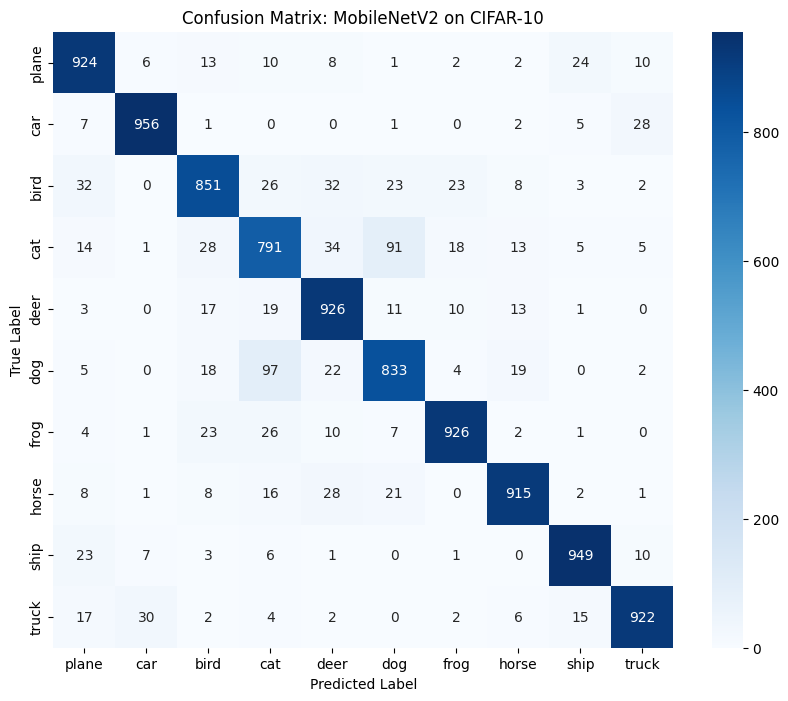

In [18]:
class_dict = {0: 'plane',
              1: 'car',
              2: 'bird',
              3: 'cat',
              4: 'deer',
              5: 'dog',
              6: 'frog',
              7: 'horse',
              8: 'ship',
              9: 'truck'}
_mat = _compute_confusion_matrix(model=model, data_loader=test_loader, device=device)
_plot_confusion_matrix(_mat, class_names=class_dict.values())

In [19]:
%watermark -iv

matplotlib : 3.7.2
numpy      : 1.26.4
pandas     : 2.2.3
seaborn    : 0.12.2
sklearn    : 1.2.2
torch      : 2.6.0+cu124
torchinfo  : 1.8.0
torchvision: 0.21.0+cu124

